In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
Cust_acq = pd.read_excel('Customer Acqusition.xlsx')
Repayment = pd.read_excel('Repayment.xlsx')
Spend = pd.read_excel('spend.xlsx')

In [30]:
del Cust_acq['No']

In [31]:
del Spend['Sl No:']

In [32]:
del Repayment['SL No:']

In [33]:
Spend.head(2)

,Customer,Month,Type,Amount
0,A1,2004-01-12,JEWELLERY,485470.80
1,A1,2004-01-03,PETRO,410556.13


In [34]:
Cust_acq.head(2)

,Customer,Age,City,Product,Limit,Company,Segment
0,A1,76,BANGALORE,Gold,500000,C1,Self Employed
1,A2,71,CALCUTTA,Silver,100000,C2,Salaried_MNC


In [35]:
Repayment.head(2)

,Customer,Month,Amount
0,A1,2004-01-12,495414.75
1,A1,2004-01-03,245899.02


### Merge Spend and Customer acqusition table 

In [36]:
Spend_Cust_acq = pd.merge(left=Spend, right=Cust_acq, left_on='Customer', right_on='Customer')
Spend_Cust_acq.shape # Here both Table joined properly 

(1500, 10)

### Merge Repayment and Customer acqusition table 

In [37]:
Repayment_Cust_acq = pd.merge(left=Repayment, right=Cust_acq, left_on='Customer', right_on='Customer')
Repayment_Cust_acq.shape # Here also both table joined properly 

(1500, 9)

#### Basic analysis on Spend_Cust_acq table and Repayment_Cust_acq

##### --**Here we will understand data and do some of analysis on it.**

In [38]:
Spend_Cust_acq.head() # It will provide first 5 rows of table 

,Customer,Month,Type,Amount,Age,City,Product,Limit,Company,Segment
0,A1,2004-01-12,JEWELLERY,485470.80,76,BANGALORE,Gold,500000,C1,Self Employed
1,A1,2004-01-03,PETRO,410556.13,76,BANGALORE,Gold,500000,C1,Self Employed
2,A1,2004-01-15,CLOTHES,23740.46,76,BANGALORE,Gold,500000,C1,Self Employed
3,A1,2004-01-25,FOOD,484342.47,76,BANGALORE,Gold,500000,C1,Self Employed
4,A1,2005-01-17,CAMERA,369694.07,76,BANGALORE,Gold,500000,C1,Self Employed


In [39]:
Spend_Cust_acq.tail()

,Customer,Month,Type,Amount,Age,City,Product,Limit,Company,Segment
1495,A67,2006-02-04,BUS TICKET,356872.73,54,CHENNAI,Gold,500000,C29,Normal Salary
1496,A68,2006-03-25,BUS TICKET,204971.10,12,TRIVANDRUM,Silver,100000,C30,Self Employed
1497,A69,2006-03-31,BUS TICKET,50449.44,33,CALCUTTA,Platimum,10000,C31,Self Employed
1498,A70,2006-03-23,BUS TICKET,80593.94,16,BOMBAY,Platimum,10001,C32,Self Employed
1499,A71,2006-03-24,BUS TICKET,194447.62,34,BOMBAY,Platimum,10002,C33,Self Employed


In [40]:
Spend_Cust_acq.info() # It will just print an information about table

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Customer  1500 non-null   object        
 1   Month     1500 non-null   datetime64[ns]
 2   Type      1500 non-null   object        
 3   Amount    1500 non-null   float64       
 4   Age       1500 non-null   int64         
 5   City      1500 non-null   object        
 6   Product   1500 non-null   object        
 7   Limit     1500 non-null   int64         
 8   Company   1500 non-null   object        
 9   Segment   1500 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(6)
memory usage: 117.3+ KB


In [41]:
Spend_Cust_acq.describe() # It gives an over view and we can also do some analysis on it 

,Month,Amount,Age,Limit
count,1500,1500.000000,1500.000000,1500.000000
mean,2005-05-16 21:17:45.600000,243096.049460,44.268667,297993.956667
min,2004-01-03 00:00:00,720.300000,12.000000,10000.000000
25%,2004-04-25 00:00:00,122606.487500,28.000000,100000.000000
50%,2005-05-29 00:00:00,239210.360000,42.000000,500000.000000
75%,2006-03-26 00:00:00,361617.632500,57.000000,500000.000000
max,2006-12-03 00:00:00,499793.490000,79.000000,500000.000000
std,NaN,141349.547367,17.512270,216239.376333


In [42]:
Percentage_dtype = Spend_Cust_acq.dtypes.value_counts(normalize=True).round(2)*100
Percentage_dtype # This will give anover view of data types are present in my table 

object            60.0
int64             20.0
datetime64[ns]    10.0
float64           10.0
Name: proportion, dtype: float64

### In case age is less than 18, replace it with mean of age values.

In [43]:
Mean_age = Spend_Cust_acq['Age'].mean().round(0)
Mean_age

np.float64(44.0)

In [44]:
Spend_Cust_acq.loc[Spend_Cust_acq['Age']<18, 'Age'] = Mean_age

In [45]:
Spend_Cust_acq.loc[Spend_Cust_acq['Age']<18].size

0

### In case spend amount is more than the limit, replace it with 50% of that customer’s limit. 
### (customer’s limit provided in acquisition table is the per transaction limit on his card)

In [46]:
Spend_Cust_acq.loc[:, ['Amount', 'Limit']]

,Amount,Limit
0,485470.80,500000
1,410556.13,500000
2,23740.46,500000
3,484342.47,500000
4,369694.07,500000
...,...,...
1495,356872.73,500000
1496,204971.10,100000
1497,50449.44,10000
1498,80593.94,10001


In [47]:
Spend_Cust_acq['Amount'] = np.where(
    Spend_Cust_acq['Amount'] > Spend_Cust_acq['Limit'],
    Spend_Cust_acq['Limit'] * 0.5,
    Spend_Cust_acq['Amount']) # Here we can use np.where it's similar to excel if condition or Use loc 
# Spend_Cust_acq.loc[
#     Spend_Cust_acq['Amount'] > Spend_Cust_acq['Limit'],
#     'Amount'
# ] = Spend_Cust_acq['Limit'] * 0.5

### Incase the repayment amount is more than the limit, replace the repayment with the limit.

In [48]:
Repayment_Cust_acq.loc[
    Repayment_Cust_acq['Amount'] > 
    Repayment_Cust_acq['Limit'],
    'Amount'
    ] = Repayment_Cust_acq['Limit']

In [49]:
Repayment_Cust_acq[['Amount', 'Limit']].max()

Amount    499930.66
Limit     500000.00
dtype: float64

In [50]:
(Repayment_Cust_acq['Amount'] > Repayment_Cust_acq['Limit']).any()

np.False_

### How many distinct customers exist?

In [51]:
Spend_Repayment_and_Cust_acq = pd.merge(left=Repayment_Cust_acq, right=Spend, left_on='Customer', right_on='Customer')

In [52]:
Spend_Repayment_and_Cust_acq['Customer'].nunique()
          # Or
#  Spend_Repayment_and_Cust_acq.Customer.unique().size 

100

### How many distinct categories exist?

In [53]:
Spend_Repayment_and_Cust_acq.Type.value_counts().size
       # Or
# Spend_Repayment_and_Cust_acq['Type'].nunique()

15

### What is the average monthly spend by customers?

In [57]:
Spend_Repayment_and_Cust_acq.columns = ['Customer', 'Month_Of_Repayment', 'Amount_Recover', 'Age', 'City', 'Product', 'Limit', 'Company', 'Segment', 'Month_Of_Spend', 'Type', 'Amount_Spend']

In [58]:
Avg_Monthly_Spend = Spend_Repayment_and_Cust_acq.groupby(
    ['Customer', Spend_Repayment_and_Cust_acq['Month_Of_Spend'].dt.month]
)['Amount_Spend'].mean().reset_index()
Avg_Monthly_Spend

,Customer,Month_Of_Spend,Amount_Spend
0,A1,1,372762.587143
1,A1,2,175235.690000
2,A1,4,261649.250000
3,A1,5,361141.310000
4,A1,8,344372.100000
...,...,...,...
573,A95,1,240401.500000
574,A96,1,54729.660000
575,A97,1,139018.260000
576,A98,1,284521.060000


###  What is the average monthly repayment by customers?

In [59]:
Avg_Monthly_Repayment = Spend_Repayment_and_Cust_acq.groupby(
    ['Customer', Spend_Repayment_and_Cust_acq['Month_Of_Repayment'].dt.month]
)['Amount_Recover'].mean().reset_index()
Avg_Monthly_Repayment.round(2)

,Customer,Month_Of_Repayment,Amount_Recover
0,A1,1,343972.33
1,A1,2,156374.76
2,A1,4,254474.58
3,A1,7,297176.74
4,A1,9,186427.50
...,...,...,...
553,A95,1,369405.96
554,A96,1,100000.00
555,A97,1,10000.00
556,A98,1,10001.00


### If the monthly rate of interest is 2.9%, what is the profit for the bank for each month? 
###(Profit is defined as interest earned on Monthly Profit. Monthly Profit = Monthly repayment – Monthly spend. Interest is earned only on positive profits and not on negative amounts)

In [60]:
monthly_repayment = Spend_Repayment_and_Cust_acq.groupby(
    Spend_Repayment_and_Cust_acq['Month_Of_Repayment'].dt.month
)['Amount_Recover'].sum()

monthly_spend = Spend_Repayment_and_Cust_acq.groupby(
    Spend_Repayment_and_Cust_acq['Month_Of_Spend'].dt.month
)['Amount_Spend'].sum()

monthly_profit = monthly_repayment - monthly_spend

bank_profit = monthly_profit.apply(
    lambda x: x * 0.029 if x > 0 else 0
)

bank_profit.round(2)

Month_Of_Repayment
1           0.00
2           0.00
3           0.00
4           0.00
5     1195815.74
6           0.00
7           0.00
8           0.00
9           0.00
10          0.00
11          0.00
12          0.00
dtype: float64

### What are the top 5 product types?

In [61]:
Top_Cat = Spend_Repayment_and_Cust_acq.groupby('Type')[['Amount_Spend']] \
.sum() \
.sort_values(by='Amount_Spend', ascending=False) \
.head(5) \
.astype('int')
Top_Cat.reset_index()

,Type,Amount_Spend
0,PETRO,1185036116
1,CAMERA,1096148633
2,FOOD,950794596
3,TRAIN TICKET,852028849
4,AIR TICKET,811752331


### Which city is having maximum spend?

In [62]:
Maximum_Spend_By_City = Spend_Repayment_and_Cust_acq.groupby('City')['Amount_Spend'] \
.sum() \
.sort_values(ascending=False) \
.head(1) \
.astype(int)
Maximum_Spend_By_City.reset_index()

,City,Amount_Spend
0,COCHIN,1806987281


#### Create Age Group 

In [69]:
conditions = [
    (Spend_Repayment_and_Cust_acq['Age'] <= 18),

    (Spend_Repayment_and_Cust_acq['Age'] > 18) &
    (Spend_Repayment_and_Cust_acq['Age'] <= 30),

    (Spend_Repayment_and_Cust_acq['Age'] > 30) &
    (Spend_Repayment_and_Cust_acq['Age'] <= 40),

    (Spend_Repayment_and_Cust_acq['Age'] > 40) &
    (Spend_Repayment_and_Cust_acq['Age'] <= 50),

    (Spend_Repayment_and_Cust_acq['Age'] > 50) &
    (Spend_Repayment_and_Cust_acq['Age'] <= 60),

    (Spend_Repayment_and_Cust_acq['Age'] > 60)
]

choices = [
    '0-18',
    '19-30',
    '31-40',
    '41-50',
    '51-60',
    '60+'
]

Spend_Repayment_and_Cust_acq['Age_Group'] = pd.Series(
    np.select(conditions, choices, default='Unknown'),
    name='Age_Group'
)

pd.concat([Spend_Repayment_and_Cust_acq, Age_Group], axis=1)

###  Which age group is spending more money?

In [ ]:
GRoup_Wise_Spending = Spend_Repayment_and_Cust_acq.groupby('Age_Group')[['Amount_Spend']] \
.sum() \
.sort_values(by='Amount_Spend', ascending=False)\
.astype('int')
GRoup_Wise_Spending.reset_index().head(1)

### Who are the top 10 customers in terms of repayment?

In [72]:
Top_Customers = Spend_Repayment_and_Cust_acq.groupby('Customer')[['Amount_Recover']] \
.sum() \
.sort_values(by='Amount_Recover', ascending=False)\
.astype('int')
Top_Customers.reset_index().head(10)

,Customer,Amount_Recover
0,A61,400487430
1,A60,375299048
2,A13,296732020
3,A43,263186015
4,A45,261898380
5,A12,258377564
6,A14,246241327
7,A44,240086633
8,A39,236296982
9,A42,236079286


### Calculate the city wise spend on each product on yearly basis. Also include a graphical representation for the same.

In [73]:
city_year_spend = Spend_Repayment_and_Cust_acq.groupby(['City', Spend_Repayment_and_Cust_acq['Month_Of_Spend'].dt.year])[['Amount_Spend']] \
.sum() \
.sort_values(by='Amount_Spend', ascending=False) \
.astype('int')
city_year_spend.reset_index()

,City,Month_Of_Spend,Amount_Spend
0,COCHIN,2005,666989426
1,CALCUTTA,2006,663192544
2,COCHIN,2006,662528781
3,BANGALORE,2005,613050319
4,BANGALORE,2006,558170471
5,CALCUTTA,2005,536662890
6,BANGALORE,2004,531131196
7,COCHIN,2004,477469073
8,BOMBAY,2006,465294489
9,BOMBAY,2005,439887675


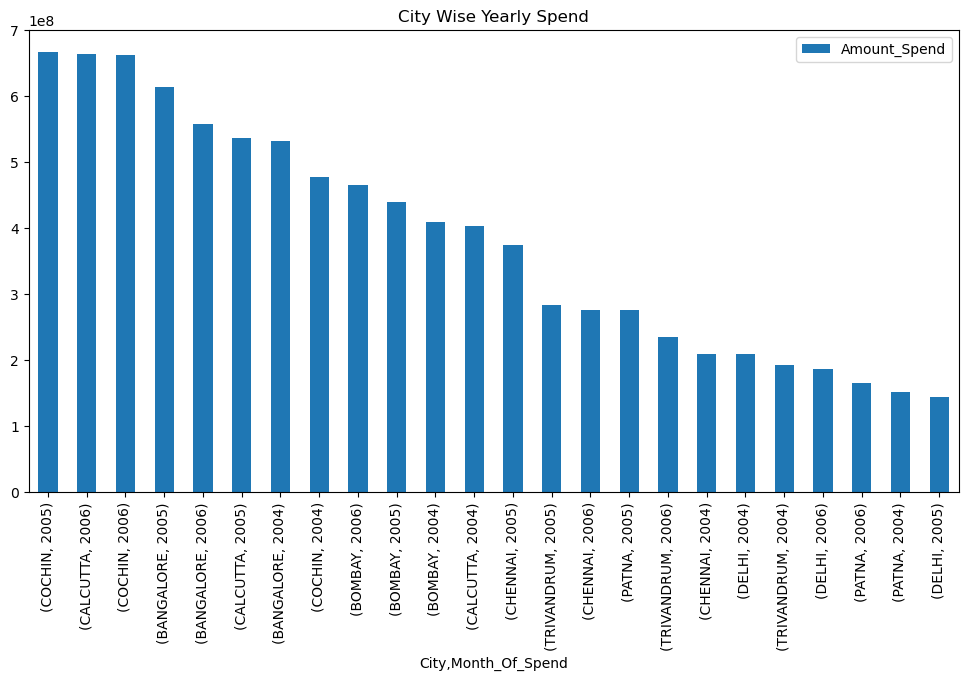

In [74]:
city_year_spend.plot(kind='bar', figsize=(12,6))

plt.title('City Wise Yearly Spend')

plt.show()

###  Monthly comparison of total spends, city wise

In [76]:
Spend_Repayment_and_Cust_acq['Month'] = Spend_Repayment_and_Cust_acq['Month_Of_Spend'].dt.month

In [107]:
monthly_city_spend = Spend_Repayment_and_Cust_acq.groupby(['Month', 'City'])['Amount_Spend'] \
    .sum() \
    .reset_index()
monthly_city_spend

,Month,City,Amount_Spend
0,1,BANGALORE,4.218778e+08
1,1,BOMBAY,2.891995e+08
2,1,CALCUTTA,3.487508e+08
3,1,CHENNAI,2.063512e+08
4,1,COCHIN,4.563068e+08
...,...,...,...
91,12,CHENNAI,4.248937e+06
92,12,COCHIN,4.520574e+07
93,12,DELHI,1.518952e+07
94,12,PATNA,6.940975e+06


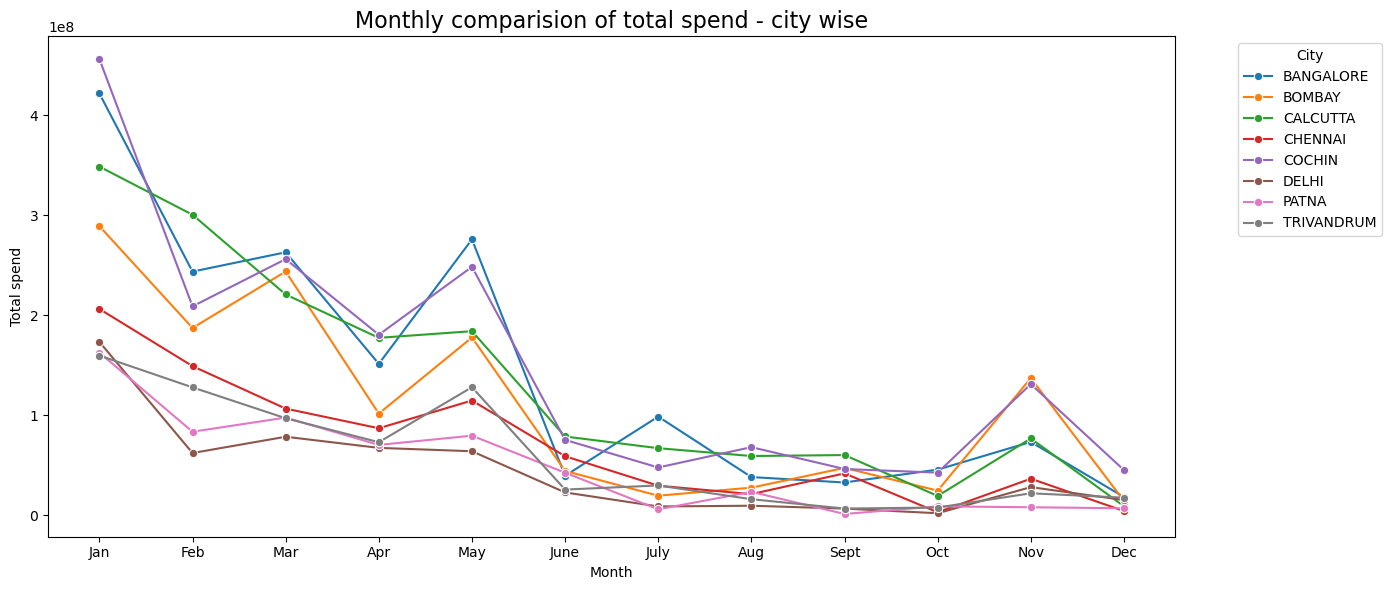

In [108]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_city_spend, x='Month', y='Amount_Spend', hue='City', marker='o')
plt.title('Monthly comparision of total spend - city wise', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Total spend')
plt.xticks(range(1,13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'June',
                        'July', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec'])
plt.legend(title='City', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Yearly comparision of total repayment by category

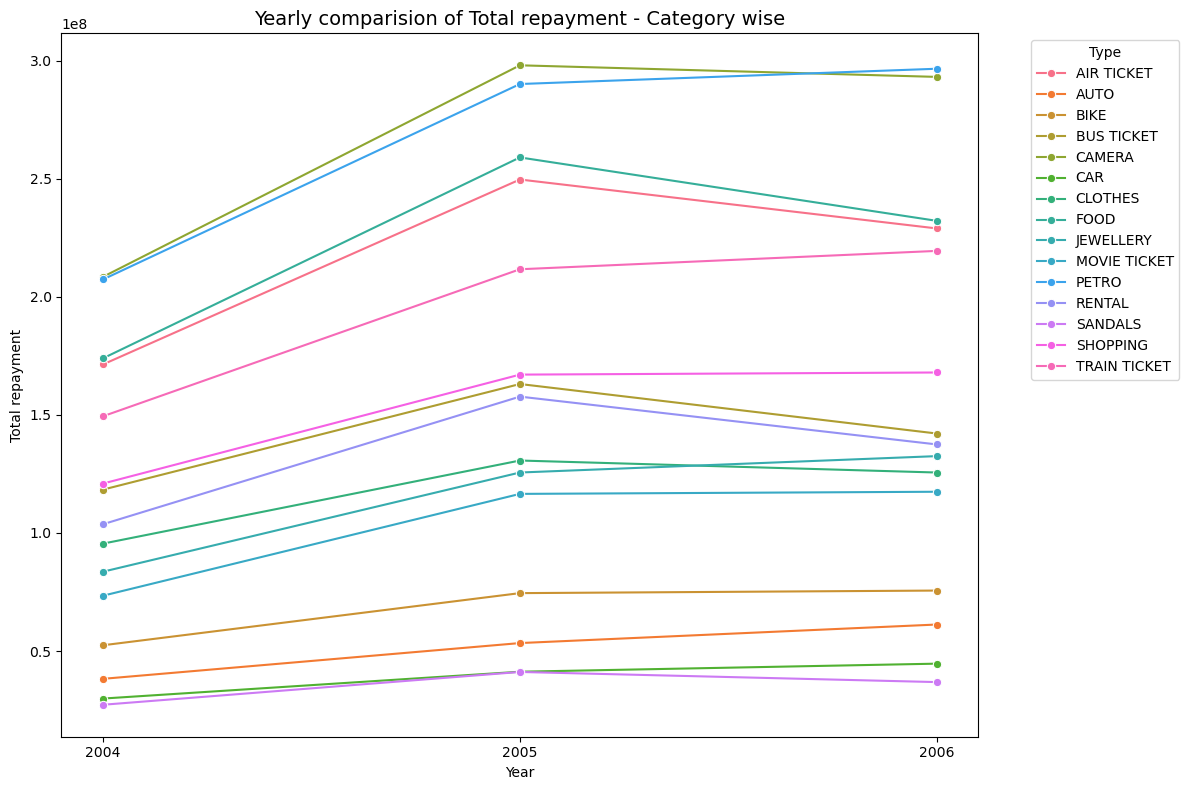

In [118]:
Spend_Repayment_and_Cust_acq['Year'] = Spend_Repayment_and_Cust_acq['Month_Of_Repayment'].dt.year

Yearly_Category_Repayment = Spend_Repayment_and_Cust_acq.groupby(['Year', 'Type'])['Amount_Recover'] \
.sum() \
.reset_index()

plt.figure(figsize=(12,8))
sns.lineplot(data=Yearly_Category_Repayment, x='Year', y='Amount_Recover', hue='Type', marker='o')
plt.title('Yearly comparision of Total repayment - Category wise', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Total repayment')
plt.xticks(Yearly_Category_Repayment['Year'].unique())
plt.legend(title='Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Comparison of yearly spend on air tickets

In [128]:
air_ticket = Spend_Repayment_and_Cust_acq[Spend_Repayment_and_Cust_acq['Type'] == 'AIR TICKET'].copy()

In [129]:
air_ticket['Year'] = air_ticket['Month_Of_Spend'].dt.year

In [132]:
yearly_air_ticket = air_ticket.groupby('Year')['Amount_Spend'].sum().reset_index()

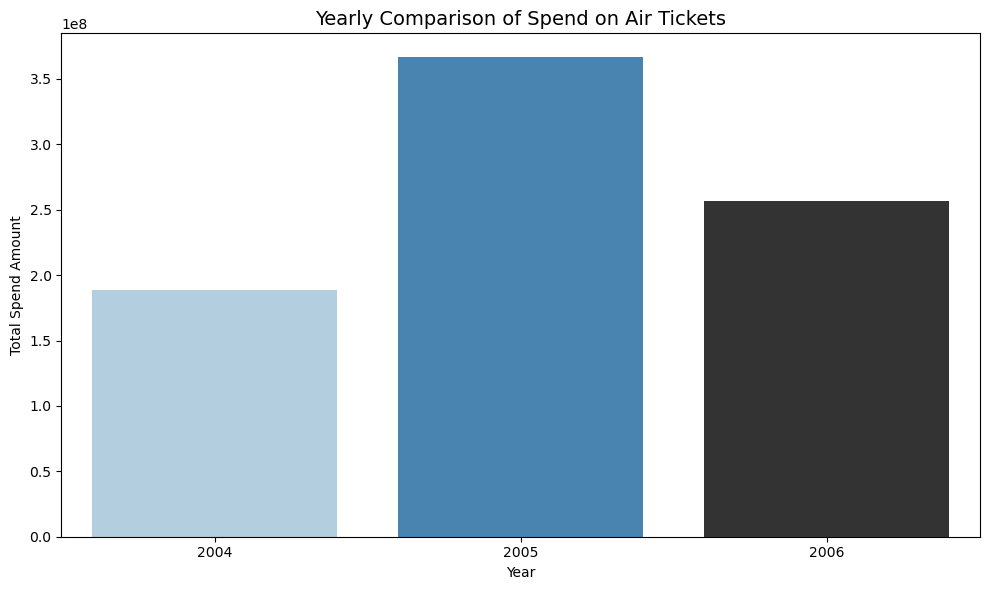

In [139]:
plt.figure(figsize=(10, 6))
sns.barplot(data=yearly_air_ticket, x='Year', y='Amount_Spend', hue='Year', palette='Blues_d',legend=False) 
plt.title('Yearly Comparison of Spend on Air Tickets', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Total Spend Amount')
plt.tight_layout()
plt.show()

### Comparison of monthly spend for each product (look for any seasonality that exists in terms of spend)

In [145]:
Spend_Repayment_and_Cust_acq['Month'] = Spend_Repayment_and_Cust_acq['Month_Of_Spend'].dt.month
Monthly_Product_wise_Spend = Spend_Repayment_and_Cust_acq.groupby(['Month', 'Type'])['Amount_Spend'] \
.sum() \
.reset_index()

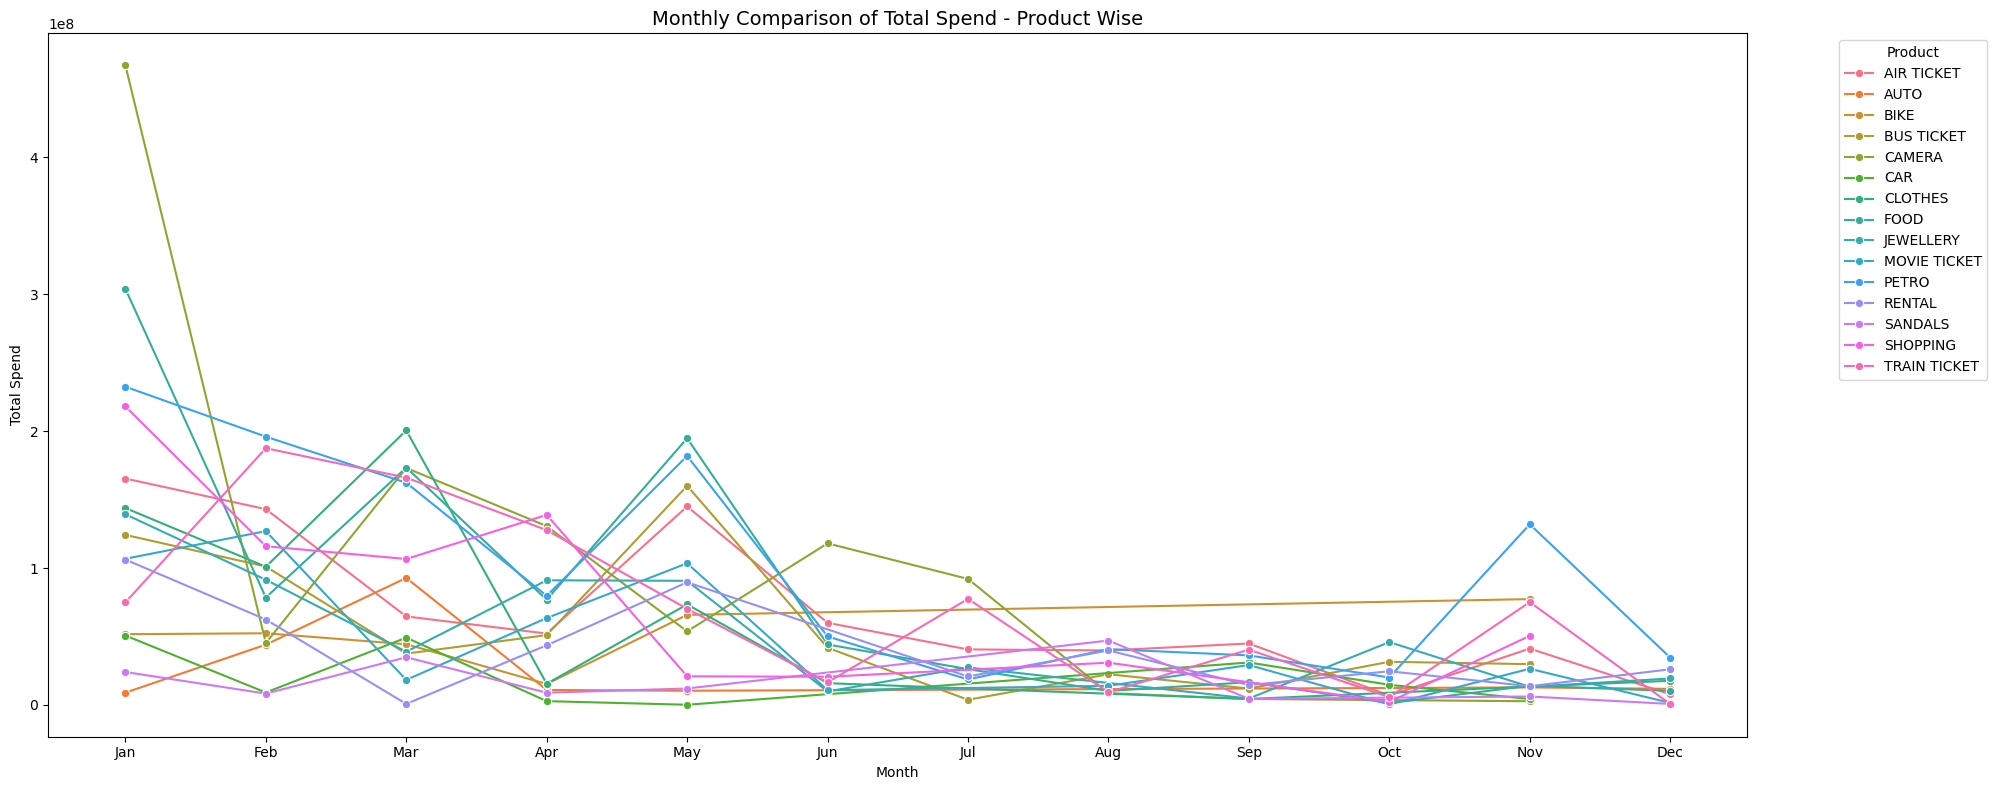

In [151]:
plt.figure(figsize=(20, 8))
sns.lineplot(data=Monthly_Product_wise_Spend, x='Month', y='Amount_Spend', 
             hue='Type', marker='o')
plt.title('Monthly Comparison of Total Spend - Product Wise', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Spend')
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend(title='Product', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [169]:
def top_10_customers(product, time_period):
    
    filtered_data = Spend_Repayment_and_Cust_acq[
        Spend_Repayment_and_Cust_acq['Product'] == product
    ].copy()

    filtered_data['City'] = filtered_data['City'].str.title()

    if time_period == 'yearly':
        filtered_data['Time'] = filtered_data['Month_Of_Repayment'].dt.year
    
    elif time_period == 'monthly':
        filtered_data['Time'] = filtered_data['Month_Of_Repayment'].dt.month

    grouped = filtered_data.groupby(['City', 'Time', 'Customer'])['Amount_Recover'] \
        .sum() \
        .reset_index()
        
    top10 = grouped.sort_values('Amount_Recover', ascending=False) \
        .groupby(['City', 'Time']) \
        .head(10)
    
    top10['Amount_Recover'] = top10['Amount_Recover'].astype(int)
    
    return top10

In [177]:
result = top_10_customers('Gold', 'monthly')

city_result = result[result['City'] == 'Delhi']
city_result

,City,Time,Customer,Amount_Recover
177,Delhi,1,A44,74887100
183,Delhi,5,A44,61632905
179,Delhi,2,A44,23118317
180,Delhi,3,A44,21582895
186,Delhi,8,A44,16724336
185,Delhi,7,A44,15560852
187,Delhi,11,A44,13363469
182,Delhi,4,A44,10746173
188,Delhi,12,A44,2470582
189,Delhi,12,A64,425228
